**IMPORTING LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor


**XGBOOST**

In [ ]:
!pip install xgboost
from xgboost import XGBRegressor

**LOADING THE DATASET**

In [ ]:
df= pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000




**DATA PREPROCESSING**

In [ ]:
def clean_column_names(df):
    df.columns = (df.columns
               .str.strip()
               .str.lower()
               .str.replace(" ", "_")
               .str.replace("[()€$]", "",regex=True))
    return df

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
cols= ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
df[cols]= df[cols].replace(0,np.nan)
imputer = SimpleImputer(strategy="median")
df[cols] = imputer.fit_transform(df[cols])

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
(df==0).sum()

,0
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


### **SPLITTING FEATURES AND TARGET PARAMETERS**

In [ ]:
X= df.drop("Glucose",axis=1)
y= df["Glucose"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Defining evaluation function**

In [ ]:
results ={}

def evaluate_model(model, name):
  preds= model.predict(X_test)
  r2 = r2_score(y_test, preds)
  mse= mean_squared_error(y_test, preds)
  mae= mean_absolute_error(y_test, preds)

  #store results
  results[name] = [r2, mse, mae]

  print(f"-----{name}-----")
  print("R2 score: ", round(r2, 4))
  print("MSE: ", round(mse, 2))
  print("MAE: ", round(mae, 2))
  print()

**Train Model**

In [ ]:
#LINEAR REGRESSION
lr= LinearRegression()
lr.fit(X_train, y_train)
evaluate_model(lr, "Linear Regression")

-----Linear Regression-----
R2 score:  0.3785
MSE:  625.42
MAE:  19.96



In [ ]:
#RANDOM FOREST REGRESSOR
rf= RandomForestRegressor()
rf.fit(X_train, y_train)
evaluate_model(rf, "Random Forest Regressor")

-----Random Forest Regressor-----
R2 score:  0.3302
MSE:  674.03
MAE:  20.96



In [ ]:
#GRADIENT BOOSTING REGRESSOR
gb= GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
evaluate_model(gb, "Gradient Boostin Regressor")

-----Gradient Boostin Regressor-----
R2 score:  0.3362
MSE:  668.02
MAE:  20.71



In [ ]:
#DECISION TREE REGRESSOR
dt= DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
evaluate_model(dt, "Decision Tree Regressor")

-----Decision Tree Regressor-----
R2 score:  -0.338
MSE:  1346.43
MAE:  28.42



In [ ]:
#Scaling the features for support vector regressor
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#SUPPORT VECTOR REGRESSOR

svr = SVR(kernel='rbf', C=100, gamma ='scale')
svr.fit(X_train_scaled, y_train)
evaluate_model(svr, "Support Vector Regressor")

-----Support Vector Regressor-----
R2 score:  -0.3116
MSE:  1319.85
MAE:  31.47



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


In [ ]:
#XGBOOST REGRESSOR

xgb= XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
evaluate_model(xgb, "XGBoost Regressor")

-----XGBoost Regressor-----
R2 score:  0.3046
MSE:  699.82
MAE:  21.3



**EVALUATION OF ALL MODELS**

In [ ]:
results_df = pd.DataFrame(results, index=["R2 Score", "MSE", "MAE"]).T
results_df

,R2 Score,MSE,MAE
Linear Regression,0.378499,625.422367,19.957799
Random Forest Regressor,0.330193,674.032795,20.963961
Gradient Boostin Regressor,0.336169,668.018603,20.705290
Decision Tree Regressor,-0.337987,1346.428571,28.415584
Support Vector Regressor,-0.311579,1319.853989,31.470860
XGBoost Regressor,0.304567,699.820799,21.300753


**PLOTTING MODEL COMPARISON**

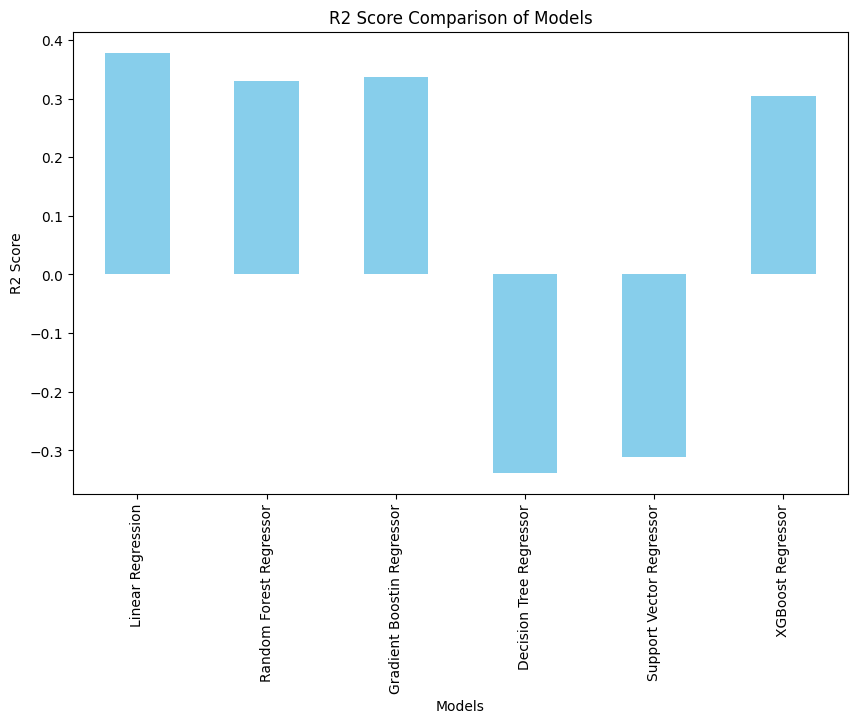

In [ ]:
#R2_score plot

plt.figure(figsize=(10, 6))
results_df['R2 Score'].plot(kind='bar', color='skyblue')
plt.title("R2 Score Comparison of Models")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

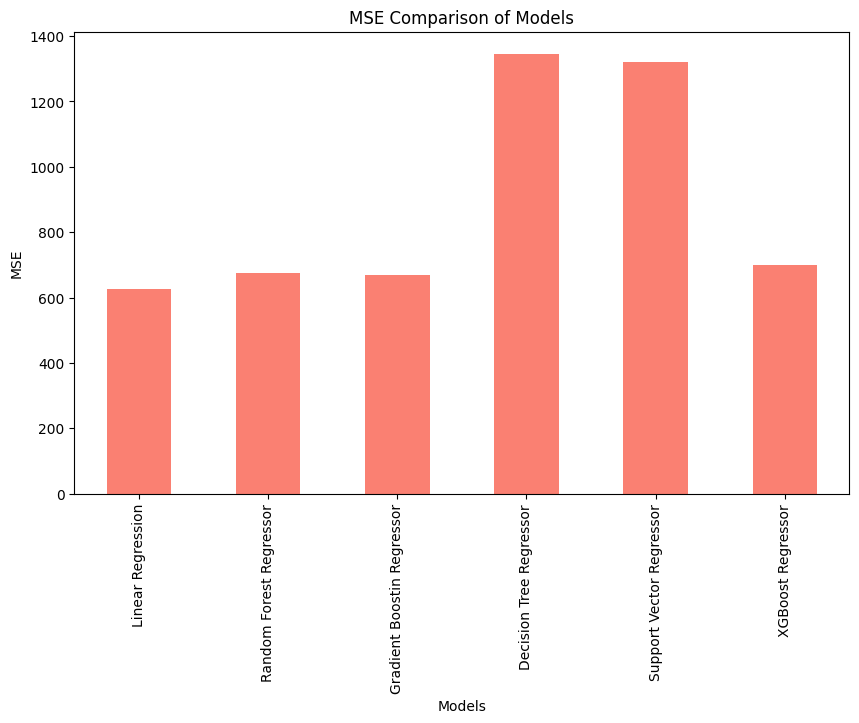

In [ ]:
#MSE plot

plt.figure(figsize=(10, 6))
results_df["MSE"].plot(kind='bar', color='salmon')
plt.title("MSE Comparison of Models")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.show()

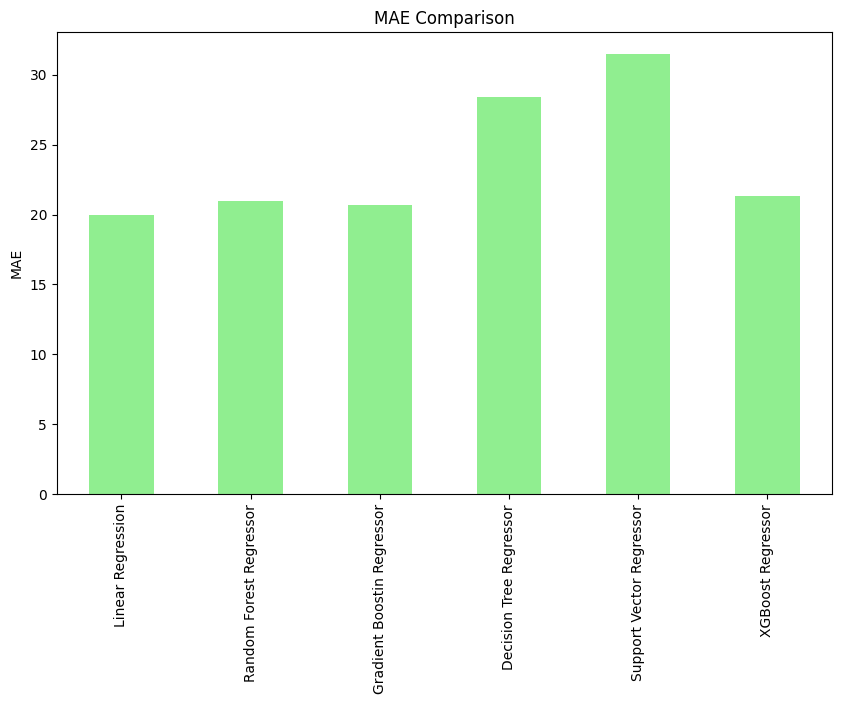

In [ ]:
#MAE plot

plt.figure(figsize=(10,6))
results_df["MAE"].plot(kind='bar', color='lightgreen')
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()

**FEATURE IMPORTANCE (TREE MODEL ONLY)**

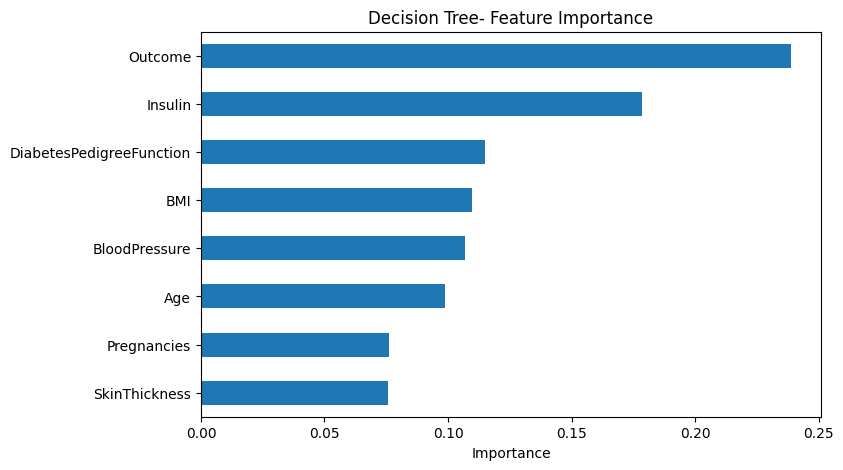

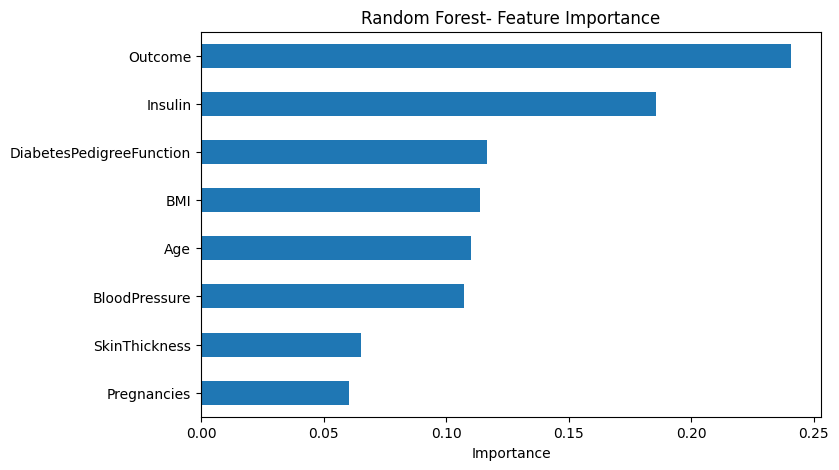

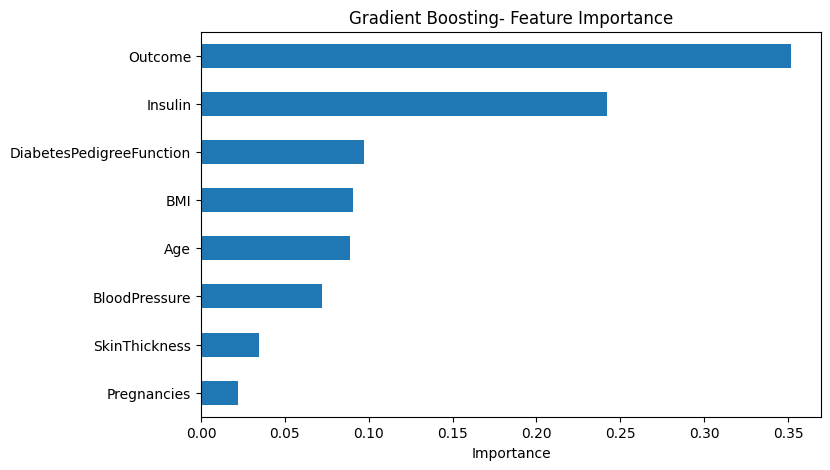

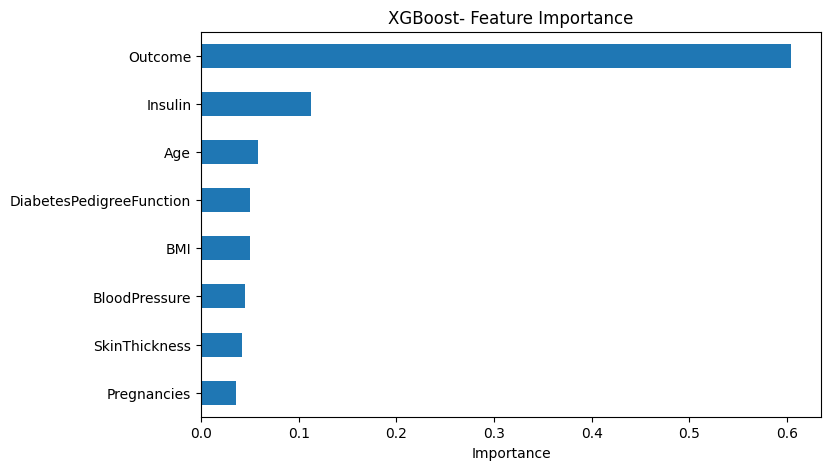

In [ ]:
tree_models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

for name, model in tree_models.items():
  plt.figure(figsize= (8,5))
  pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
  plt.title(f"{name}- Feature Importance")
  plt.xlabel("Importance")
  plt.show()


**CORRELATION HEATMAP**

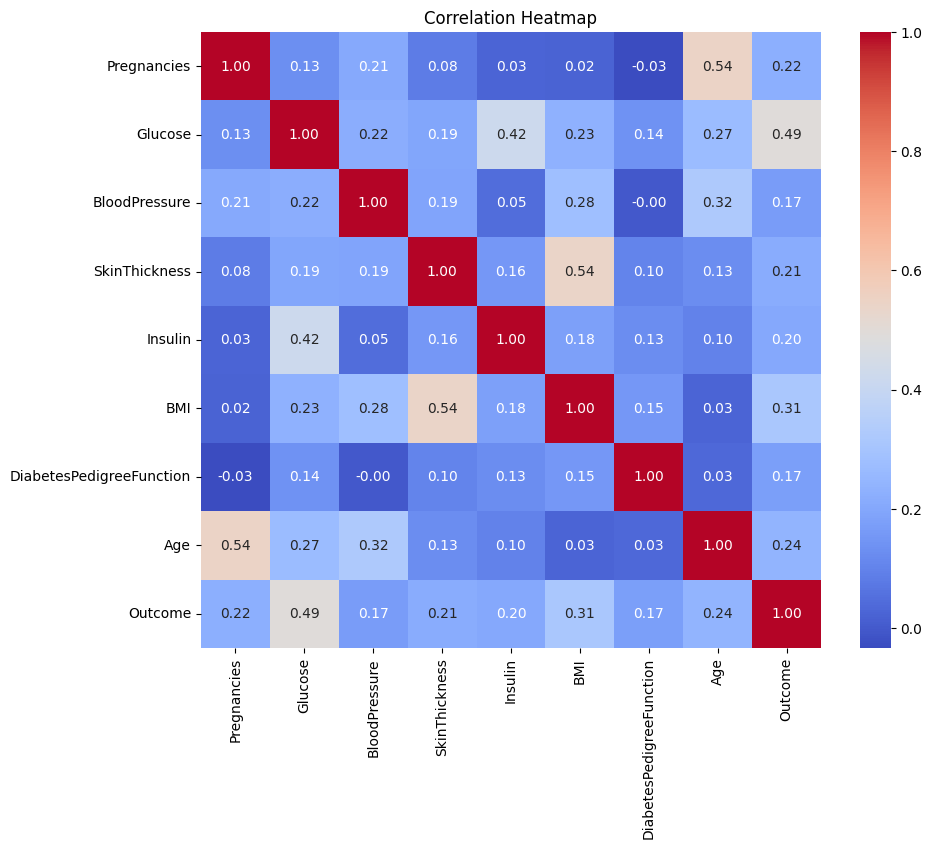

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**PREDICTION vs ACTUAL PLOT (for each model)**

In [ ]:
def plot_predictions(model, name, scaled=False):
  if scaled:
    preds= model.predict(X_test_scaled)
  else:
    preds= model.predict(X_test)

  plt.figure(figsize=(6,6))
  plt.scatter(y_test, preds, alpha=0.6)
  plt.xlabel("Actual Glucose")
  plt.ylabel("Predicted Glucose")
  plt.title(f"Actual vs Predicted - {name}")
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
  plt.show()

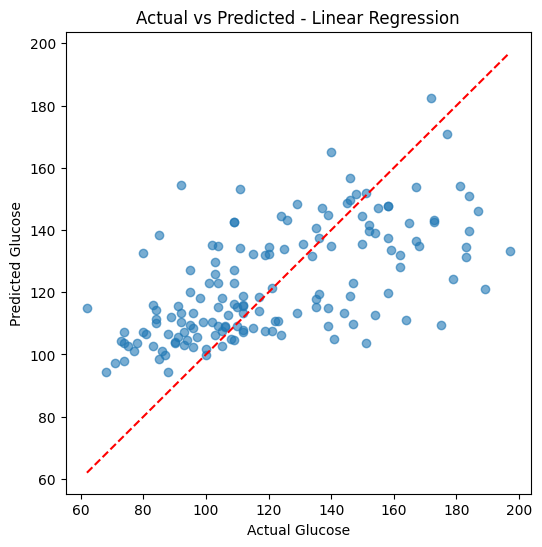

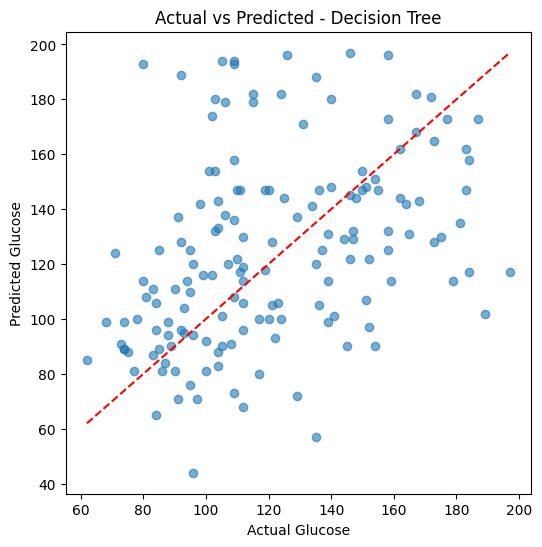

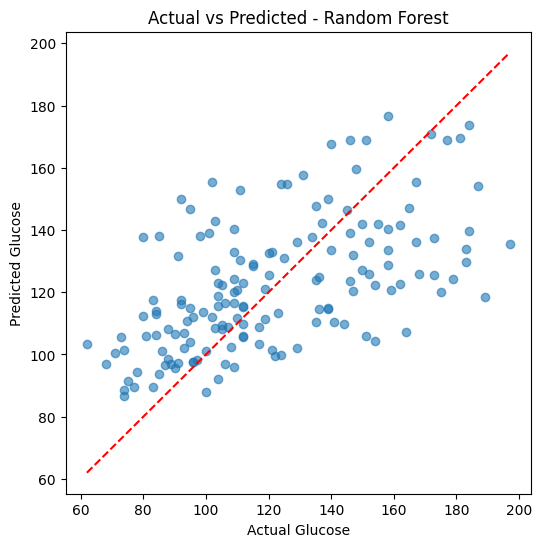

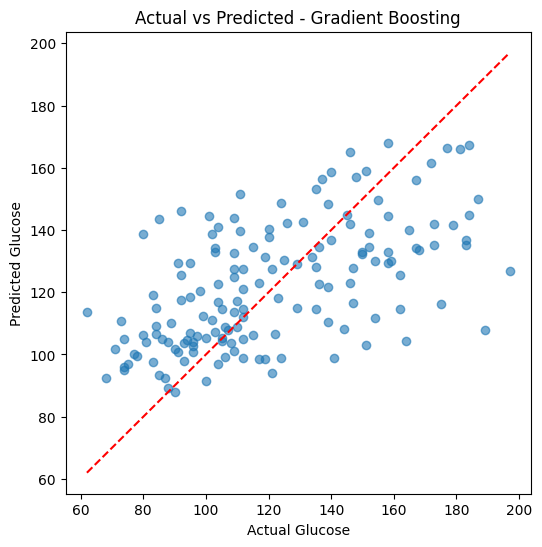

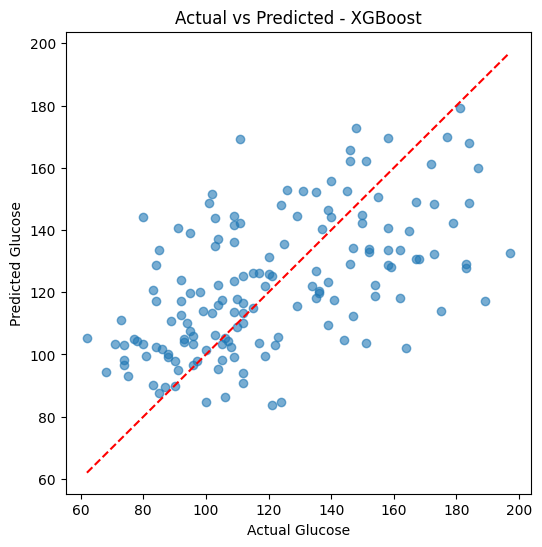

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


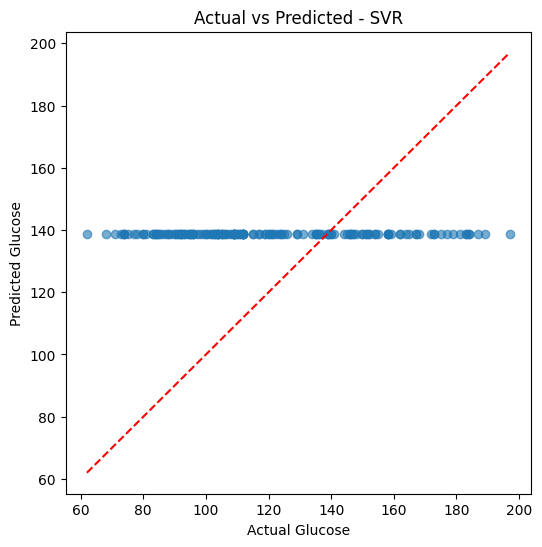

In [ ]:
#Call the function for each model

plot_predictions(lr, "Linear Regression")
plot_predictions(dt, "Decision Tree")
plot_predictions(rf, "Random Forest")
plot_predictions(gb, "Gradient Boosting")
plot_predictions(xgb, "XGBoost")
plot_predictions(svr, "SVR")